In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")   # 如果你的 notebook 不在 P10-Final-Project 目录里，这里改路径

def summary_stats(x):
    x = pd.Series(x).dropna()
    return pd.Series({
        "mean": x.mean(),
        "std": x.std(),
        "min": x.min(),
        "max": x.max(),
        "n_obs": x.shape[0]
    })

def exclude_windows(index, windows):
    mask = pd.Series(True, index=index)
    for start, end in windows.values():
        mask &= ~((index >= pd.Timestamp(start)) & (index <= pd.Timestamp(end)))
    return mask

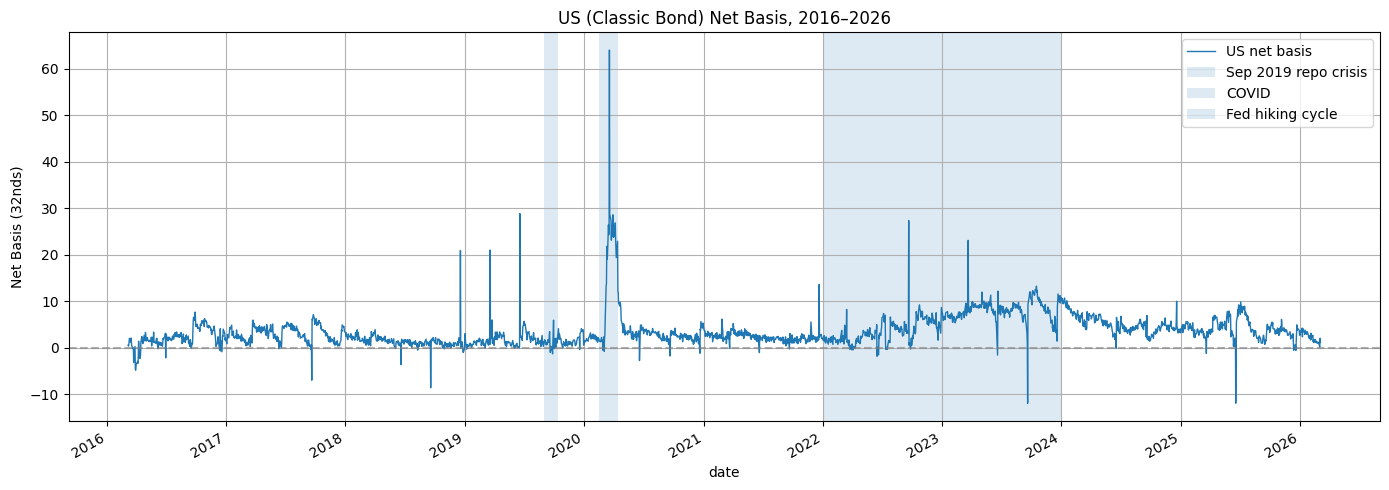

,mean,std,min,max,n_obs
Normal periods,2.87,2.22,-11.90,28.88,1923.0
Sep 2019 repo crisis,1.21,1.49,-1.30,5.96,30.0
COVID,16.39,13.12,-0.74,64.05,41.0
Fed hiking cycle,5.76,3.53,-11.93,27.38,499.0


In [8]:
# Q5(a)

basis_net = pd.read_excel(
    DATA_DIR / "treasury_basis.xlsx",
    sheet_name="net_basis_32nds",
    index_col="date",
    parse_dates=True
).sort_index()

us = basis_net["US"].loc["2016":"2026"].dropna()

stress_windows = {
    "Sep 2019 repo crisis": ("2019-09-01", "2019-10-15"),
    "COVID": ("2020-02-15", "2020-04-15"),
    "Fed hiking cycle": ("2022-01-01", "2023-12-31"),
}

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
us.plot(ax=ax, lw=1.0, color="C0", label="US net basis")
for i, (label, (start, end)) in enumerate(stress_windows.items()):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=label)
ax.axhline(0, color="gray", linestyle="--", alpha=0.6)
ax.set_title("US (Classic Bond) Net Basis, 2016–2026")
ax.set_ylabel("Net Basis (32nds)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Stats
stats = {}
normal_mask = exclude_windows(us.index, stress_windows)
stats["Normal periods"] = summary_stats(us[normal_mask])

for label, (start, end) in stress_windows.items():
    stats[label] = summary_stats(us.loc[start:end])

stats_df = pd.DataFrame(stats).T[["mean", "std", "min", "max", "n_obs"]].round(2)
display(stats_df)

The figure above plots the US (Classic Bond) net basis from 2016–2026 and highlights three stress episodes: the September 2019 repo crisis, the COVID market disruption, and the 2022–2023 Fed hiking cycle.

During normal periods, the net basis is relatively stable with an average of about 2.87 32nds and a standard deviation of 2.22. This suggests that outside crisis periods, the Treasury basis is typically small and fluctuates within a narrow range.

In contrast, the stress periods exhibit significantly larger deviations. The COVID episode shows the most extreme dislocation, with a mean net basis of 16.39 and a maximum exceeding 64 32nds, indicating severe market disruption and liquidity stress in Treasury markets.

The September 2019 repo crisis appears shorter and less extreme in magnitude, though it still shows elevated volatility compared to normal periods. Finally, the Fed hiking cycle from 2022–2023 displays moderately higher basis levels and volatility relative to normal periods, reflecting the impact of rapidly changing interest rates and funding conditions.

Overall, these results show that Treasury basis behavior becomes significantly more volatile during market stress, particularly when funding markets or liquidity conditions deteriorate.

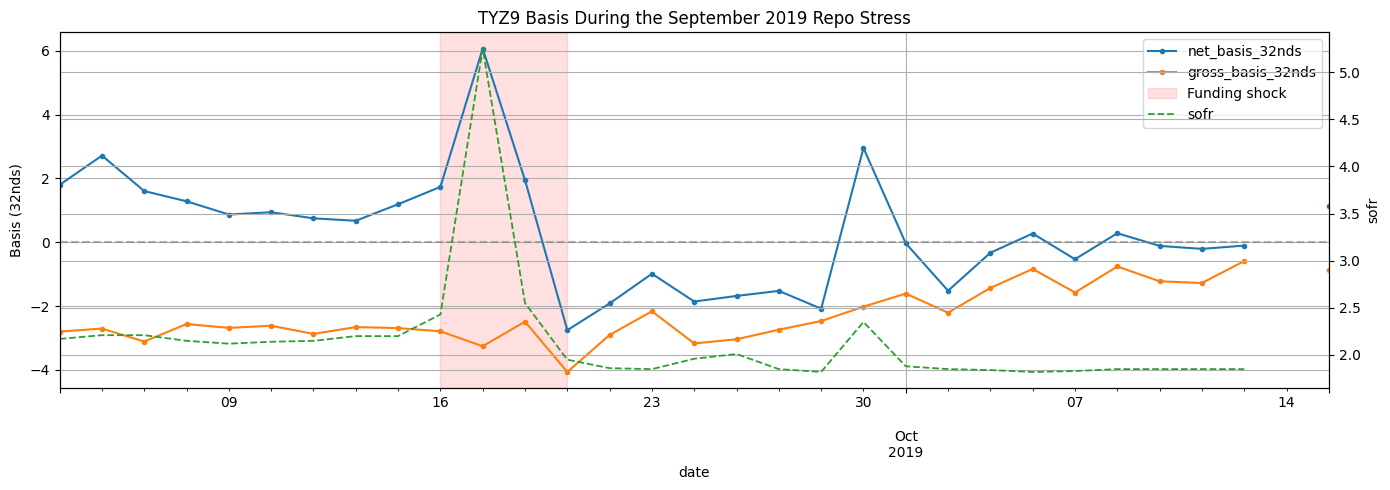

,net_basis_32nds,gross_basis_32nds,sofr
date,,,
2019-09-13,1.1908,-2.6887,2.20
2019-09-17,6.0704,-3.2579,5.25
2019-09-19,-2.7552,-4.0633,1.95
2019-09-30,2.9523,-2.0182,2.35


In [9]:
# Q5(b)

tyz9 = pd.read_excel(
    DATA_DIR / "fut_bond_data_TYZ9_2019-09.xlsx",
    sheet_name="daily",
    index_col=0,
    parse_dates=True
).sort_index()

# try to detect funding-rate column
rate_col = None
for c in tyz9.columns:
    cl = c.lower()
    if "sofr" in cl or "repo" in cl:
        rate_col = c
        break

fig, ax1 = plt.subplots(figsize=(14, 5))
tyz9[["net_basis_32nds", "gross_basis_32nds"]].plot(
    ax=ax1, marker="o", markersize=3
)
ax1.axhline(0, color="gray", linestyle="--", alpha=0.6)
ax1.axvspan(pd.Timestamp("2019-09-16"), pd.Timestamp("2019-09-19"),
            color="red", alpha=0.12, label="Funding shock")
ax1.set_ylabel("Basis (32nds)")
ax1.set_title("TYZ9 Basis During the September 2019 Repo Stress")

if rate_col is not None:
    ax2 = ax1.twinx()
    tyz9[rate_col].plot(ax=ax2, linestyle="--", linewidth=1.3, color="C2", label=rate_col)
    ax2.set_ylabel(rate_col)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
else:
    ax1.legend(loc="best")

plt.tight_layout()
plt.show()

# Useful snapshot table for writing
snapshot_dates = ["2019-09-13", "2019-09-17", "2019-09-19", "2019-09-30"]
cols = ["net_basis_32nds", "gross_basis_32nds"]
if rate_col is not None:
    cols.append(rate_col)

display(tyz9.loc[snapshot_dates, cols].round(4))

The figure shows the behavior of the TYZ9 Treasury futures basis during the September 2019 repo market stress. Around September 16–17, SOFR spikes sharply from about 2.2% to above 5%, reflecting severe funding pressure in the repo market.

At the same time, the net basis increases dramatically, rising from about 1.19 on September 13 to more than 6 on September 17. This indicates a significant dislocation in the Treasury futures basis during the funding shock.

The reason is that basis trades typically involve going long the cash Treasury bond and short the futures contract while financing the bond in the repo market. When repo rates spike, the funding cost of holding the bond rises sharply, making the basis trade less attractive and forcing some traders to unwind positions.

This funding stress causes large and sudden movements in the observed basis. After the Federal Reserve intervened in the repo market and funding conditions stabilized, both SOFR and the Treasury basis quickly returned closer to normal levels.

Overall, this episode illustrates how Treasury basis dynamics can be strongly influenced by funding market conditions, particularly during periods of liquidity stress.

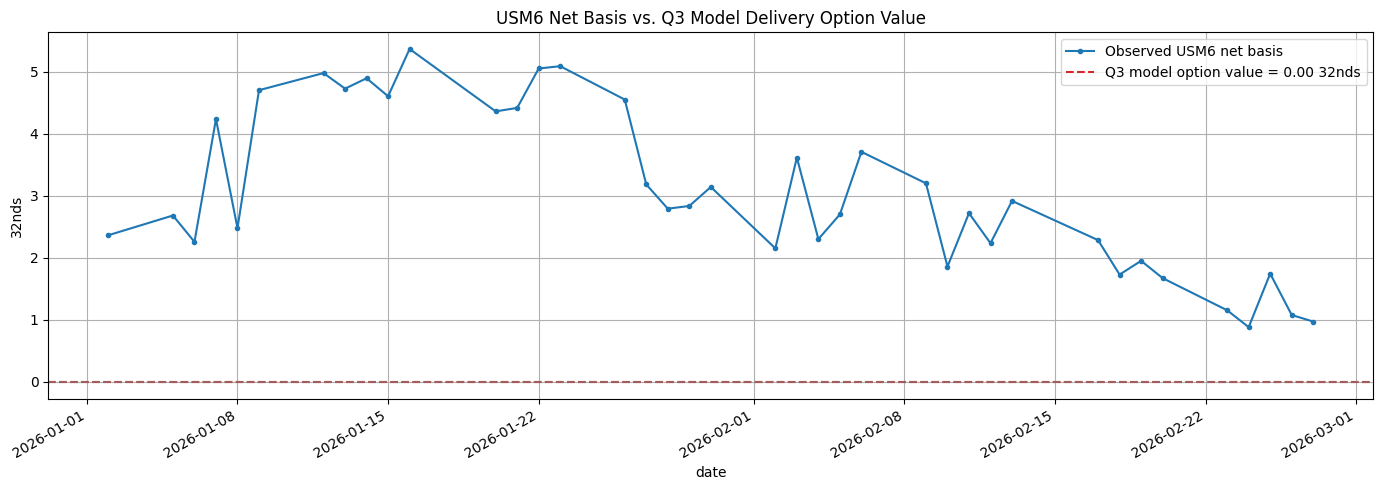

,value
Q3 model option value (32nds),0.00
Observed mean USM6 net basis (32nds),3.07
Observed std USM6 net basis (32nds),1.32
Observed min USM6 net basis (32nds),0.88
Observed max USM6 net basis (32nds),5.37
Mean minus model (32nds),3.07


In [10]:
# Q5(c)

usm6_file = sorted(DATA_DIR.glob("fut_bond_data_USM6_*.xlsx"))[-1]

us_daily = pd.read_excel(
    usm6_file,
    sheet_name="daily",
    index_col=0,
    parse_dates=True
).sort_index()

# ---- replace this with your Q3 result ----
option_value_32 = 0.00
# Example if your Q3 result dict is still in memory:
# option_value_32 = q3_result["option_value_32"]

fig, ax = plt.subplots(figsize=(14, 5))
us_daily["net_basis_32nds"].plot(
    ax=ax, marker="o", markersize=3, label="Observed USM6 net basis"
)
ax.axhline(
    option_value_32,
    color="C3",
    linestyle="--",
    linewidth=1.5,
    label=f"Q3 model option value = {option_value_32:.2f} 32nds"
)
ax.axhline(0, color="gray", linestyle="--", alpha=0.6)
ax.set_title("USM6 Net Basis vs. Q3 Model Delivery Option Value")
ax.set_ylabel("32nds")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

comparison = pd.Series({
    "Q3 model option value (32nds)": option_value_32,
    "Observed mean USM6 net basis (32nds)": us_daily["net_basis_32nds"].mean(),
    "Observed std USM6 net basis (32nds)": us_daily["net_basis_32nds"].std(),
    "Observed min USM6 net basis (32nds)": us_daily["net_basis_32nds"].min(),
    "Observed max USM6 net basis (32nds)": us_daily["net_basis_32nds"].max(),
    "Mean minus model (32nds)": us_daily["net_basis_32nds"].mean() - option_value_32,
}).to_frame("value")

display(comparison.round(2))

The figure compares the observed USM6 net basis with the delivery option value estimated from the Q3 interest-rate tree model.

The model-implied delivery option value is approximately 0.00 (in 32nds), while the observed net basis averages about 3.07 (32nds) over the sample period. This indicates that the delivery option alone explains only a small portion of the observed Treasury futures basis.

The difference arises because the model isolates only the CTD switching option embedded in Treasury futures. In practice, the observed basis also reflects other market forces such as funding costs, liquidity conditions, balance sheet constraints, and transaction costs.

In particular, basis trades typically involve financing Treasury bonds in the repo market. Changes in repo funding rates, dealer balance sheet capacity, and market liquidity can all affect the observed basis but are not captured by the simple interest-rate tree model.

Therefore, while the delivery option contributes to the theoretical value of the basis, a substantial portion of the observed basis reflects broader market frictions and funding conditions rather than purely the embedded delivery option.

Q5(d)

The tree model breaks down when basis movements are dominated by forces outside the state-contingent delivery option. In theory, net basis is affected by daily settlement effects and by the timing and quality options embedded in Treasury futures. In practice, however, the basis is also shaped by repo funding costs, dealer balance-sheet constraints, regulatory capital, leverage, and scarcity in specific issues.

The September 2019 episode was primarily a funding shock. Repo rates spiked abruptly, SOFR moved above 5 percent, and the TY basis widened sharply over just a few days. That behavior is difficult to reconcile with a small change in intrinsic delivery optionality; it is much more naturally explained by a sudden rise in funding stress and carry deterioration.

The March 2020 episode was different. There, the dominant force was not simply repo stress but a broader dash-for-cash and a deterioration in Treasury market functioning. Investors sold Treasuries aggressively, liquidity worsened, and basis trades became exposed to large liquidity and margin risk. In that environment, a no-arbitrage tree model is too narrow because it does not capture forced deleveraging or impaired intermediation.

The 2022–2023 hiking cycle reflects yet another mechanism. Rather than one acute plumbing shock, it was a regime of high interest-rate volatility, sharply changing yields, and shifting demand for duration. Those conditions affected liquidity and the willingness of intermediaries to absorb risk, so observed basis levels reflected more than just delivery optionality.

Across the course, the broader lesson is that pricing theory gives the correct benchmark, but actual basis dynamics are filtered through funding markets and market structure. Chapter 4 gives the carry-and-basis decomposition, Chapter 5 emphasizes financing and intermediation frictions, and Chapter 9 gives the numerical machinery for valuing the delivery option. Q5 shows why all three perspectives are needed.

Q6

(a)

The timing option is likely to have the largest quantitative impact, while the end-of-month option is likely the smallest, with the wild-card option somewhere in between.

The timing option allows the short to choose which day during the delivery month to deliver the bond. Because the delivery month spans many trading days, this option provides a relatively large time window over which interest rates and relative bond prices may change. Since Treasury bond prices are highly sensitive to interest rate movements, even moderate yield changes over a month can alter which bond becomes CTD. As a result, the timing option typically carries the largest economic value.

The wild-card option allows the short to declare delivery after the 2 p.m. futures settlement price is fixed while cash Treasury bonds continue trading afterward. This option becomes valuable if there are meaningful after-hours price movements, but the available window is short compared with the full delivery month, so its value is generally smaller than the timing option.

Finally, the end-of-month option allows delivery to occur for several business days after futures trading ends using the final settlement price. Because this window is short and occurs only once near the end of the contract life, it provides relatively limited flexibility and therefore tends to have the smallest option value.

(b)

The expected delivery option value across the three Treasury futures contracts should follow the ranking:

US (classic bond) > WN (ultra bond) > TY (10-year note)

The US contract has the largest delivery option value because it has the widest deliverable basket, including bonds with a broad range of maturities and coupons. Under the Treasury futures conversion factor system, bonds are adjusted assuming a 6% yield. When market yields differ from 6%, bonds with different coupons and durations will not be perfectly equalized, creating dispersion in adjusted delivery values. With a larger and more diverse basket, there are more potential candidates for the CTD bond, increasing the value of the quality option.

The WN contract has a narrower basket than the US contract but still contains very long-duration bonds. Because long-duration bonds are highly sensitive to interest rate changes, there is still meaningful potential for changes in relative prices across deliverables. However, the basket is less diverse than that of the US contract, so the delivery option value is somewhat smaller.

The TY contract has the smallest delivery option value because its deliverable basket is relatively narrow and concentrated in shorter-maturity securities. These bonds are more similar in duration and coupon, which reduces dispersion in adjusted delivery values and lowers the likelihood of CTD switching across different interest-rate scenarios.

Summary

Overall, the analysis suggests that the delivery option in the current environment is small, even though the US classic bond contract has a wide deliverable basket and meaningful theoretical scope for CTD optionality. The reason is that, while the basket is broad, the current yield environment appears to generate little effective CTD switching at relevant states, so the short’s quality option has limited incremental value today. This is consistent with the tree-based valuation result, which produces a model-implied delivery option value close to 0.00 32nds, while the observed recent USM6 net basis remains positive on average at about 3.07 32nds. In other words, the contract is structurally capable of embedding delivery optionality, but under the current curve and volatility conditions that optionality is not very large in practice. The underlying drivers of delivery option value are the shape and level of the yield curve, interest-rate volatility, and the amount of dispersion across the deliverable basket created by the conversion factor system. When market yields move away from the 6% conversion-factor benchmark, differences in coupon and duration matter more, making CTD switching more likely and increasing the value of the short’s option.

At the same time, the project shows that the tree model succeeds as a structural pricing benchmark but fails as a complete explanation of the observed basis during stress periods. In normal markets, the model is useful because it isolates the contribution of delivery optionality and clarifies how futures can be depressed relative to cash when the short holds a valuable delivery right. But the historical basis analysis shows that, during episodes such as the September 2019 repo shock, the COVID Treasury market disruption, and even the 2022–2023 hiking cycle, observed basis movements are far larger and more unstable than can be explained by CTD switching alone. Those episodes are driven by repo funding costs, liquidity stress, dealer balance-sheet constraints, and broader market frictions, all of which lie outside the BDT tree. So the main conclusion is that the delivery option is a real but currently modest component of Treasury futures pricing, while the observed basis—especially in stressed markets—reflects a much broader set of funding and market-structure forces than the tree model can capture.